<h1>Import dependencies<h1>

In [1]:
import tensorflow as tf
import os 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,RandomCrop,RandomZoom,RandomFlip,RandomBrightness,Dropout,
    Layer,RandomRotation,Input,LeakyReLU,GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.losses import Loss
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import Metric
from tensorflow.keras.applications import EfficientNetV2B0

import kagglehub
import matplotlib.pyplot as plt
from uuid import uuid4

2026-06-01 10:19:54.363759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780309194.620193      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780309194.691981      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780309195.255264      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780309195.255301      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780309195.255304      22 computation_placer.cc:177] computation placer alr

<h1>Download Dataset<h1>

In [2]:
os.environ['KAGGLEHUB_CACHE'] = './data'
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kaustubhb999/tomatoleaf


<h1>Define Variables<h1>

In [3]:
TRAIN_PATH = os.path.join(path,'tomato','train')
VAL_PATH = os.path.join(path,'tomato',"val")
W,H,D = 128,128,3
N_CLASSES = len(os.listdir(TRAIN_PATH))
LEARNING_RATE = 1e-3
EPOCHS = 40
BATCH_SIZE = 32
data_dict = {label:i for i,label in enumerate(sorted(os.listdir(TRAIN_PATH)))}
inverse_data_dict = {i:label for i,label in enumerate(sorted(os.listdir(TRAIN_PATH)))}
os.makedirs("./models", exist_ok=True)

<h1>Extract images paths and labels<h1>

In [4]:
def get_data(dir_path):
    DATA = []
    TARGETS = []
    labels = sorted(os.listdir(dir_path))
    for label in labels:
        new_path = os.path.join(dir_path,label)
        images = os.listdir(new_path)

        for image in images:
            image_path = os.path.join(new_path,image)
            DATA.append(image_path)
            TARGETS.append(data_dict[label])


    return DATA,TARGETS

In [5]:
TRAIN_DATA,TRAIN_TARGETS = get_data(TRAIN_PATH)
VAL_DATA,VAL_TARGETS = get_data(VAL_PATH)
SHUFFLE_BUFFER = len(TRAIN_DATA)

<h1>Creating Pipeline<h1>

<h5>Preprocessing<h5>

In [6]:
def preprocessing(data,label):
    img = tf.io.decode_jpeg(tf.io.read_file(data),channels=D)
    img = tf.image.resize(img,size=[W,H])
    img = tf.cast(img,dtype=tf.float32)

    label = tf.cast(label,dtype=tf.int32)

    return img,label

In [7]:
def get_pipeline(data,labels,shuffle_ok):
    DATASET = tf.data.Dataset.from_tensor_slices((data,labels))
    if shuffle_ok:
        DATASET = DATASET.shuffle(buffer_size=SHUFFLE_BUFFER)
    DATASET = DATASET.map(preprocessing,num_parallel_calls=tf.data.AUTOTUNE)
    DATASET = DATASET.cache()
    DATASET = DATASET.batch(BATCH_SIZE)
    DATASET = DATASET.prefetch(tf.data.AUTOTUNE)

    return DATASET

<h5>Data Partitioning<h5>

In [8]:
DATA = get_pipeline(TRAIN_DATA,TRAIN_TARGETS,shuffle_ok=True) 

TEST = get_pipeline(VAL_DATA,VAL_TARGETS,shuffle_ok=False)  #For eval
TRAIN = DATA.take(int(len(DATA)*.9))                        #For train
VAL = DATA.skip(int(len(DATA)*.9))                          #For val

print(f"train: {len(TRAIN)}\ntest: {len(TEST)}\nval: {len(VAL)}")

train: 281
test: 32
val: 32


I0000 00:00:1780309214.029225      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780309214.035203      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


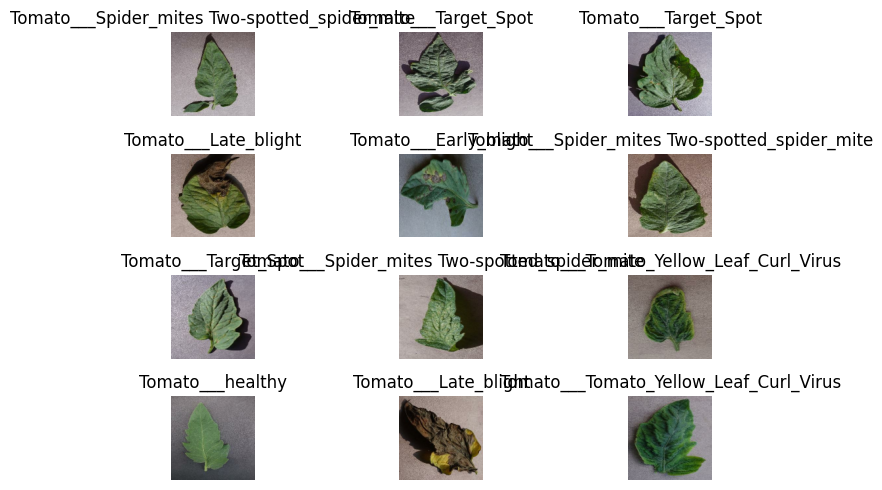

In [9]:
fig,ax = plt.subplots(4,3,figsize=(8,5))
ax =ax.flatten()
ds,lbl = TRAIN.as_numpy_iterator().next()
ds = ds/255.0

for i in range(12):
    ax[i].imshow(ds[i])
    ax[i].set_title(inverse_data_dict[int(lbl[i])])
    ax[i].axis('off')

fig.tight_layout()

plt.show()


<h1>Model Creating<h1>

In [10]:
class Base_layer(Layer):
    def __init__(self,img_shape=(W,H,D)):
        super(Base_layer,self).__init__()
        self.img_shape = img_shape
        self.base_model = EfficientNetV2B0(include_top=False,weights='imagenet',input_shape=img_shape)
        self.base_model.trainable = True

    
    def call(self,x,training=False):
        x = self.base_model(x)

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "img_shape":self.img_shape
        })
        return config
   

In [11]:
class Aug_layer(Layer):
    def __init__(self):
        super(Aug_layer,self).__init__()
        self.rotate = RandomRotation(0.03)
        self.zoom = RandomZoom(0.1)
        self.briteness = RandomBrightness(0.1)
        self.flip = RandomFlip('horizontal')


    def call(self,image,training=False):
        if training:
            image = self.rotate(image)
            image = self.zoom(image)
            image = self.briteness(image)
            image = self.flip(image)
        
        return image

    def get_config(self):      
        return super().get_config()


In [12]:
class Dense_layer(Layer):
    def __init__(self,units=[256,128,64],drop_units=[0.3, 0.2,0.1],kernel_initializer="he_normal"):
        super(Dense_layer,self).__init__()
        self.units = units
        self.drop_units = drop_units
        self.kernel_initializer=kernel_initializer
        
        self.dense_layer = [
            [Dense(units=dense_unit,activation='relu',kernel_initializer=kernel_initializer),
            Dropout(drop_unit) ]
            for (dense_unit,drop_unit) in zip(units,drop_units)
            ]
        
    def call(self,x):
        for layers in self.dense_layer:
            for layer in layers:
                x = layer(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update(
            {'units':self.units,
            'drop_units':self.drop_units,
            'kernel_initializer':self.kernel_initializer
            }
        )

        return config
        

In [13]:
earlystop = callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True,start_from_epoch=10)

class callback_clz(Callback):
    def __init__(self):
        super(callback_clz,self).__init__()
        self.save_nb = 10
    def on_epoch_end(self,epoch,logs=None):
        if epoch%self.save_nb==0 and epoch!=0:
            model_name = f"./models/model_{epoch}.keras"
            model.save(model_name)
            print(f"\nmodel saved on {epoch}th epoch")

all_callbacks = [earlystop,callback_clz()]

In [14]:
def build_model(input_size):
    input_layer = Input(shape=input_size)

    x = Aug_layer()(input_layer)
    x = Base_layer()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense_layer()(x)

    output_layer = Dense(units=N_CLASSES,activation='softmax')(x)
    model = Model(input_layer,output_layer)
    model.summary()  

    return model

In [15]:
model = build_model(input_size=(W,H,D))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'aug_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_layer (Aug_layer)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ base_layer (Base_layer)         │ (None, 4, 4, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense_layer)       │ (None, 64)             │       369,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,289,050 (23.99 MB)

 Trainable params: 6,228,442 (23.76 MB)

 Non-trainable params: 60,608 (236.75 KB)

<h1>Compile and Train</h1>

In [16]:
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer,loss=SparseCategoricalCrossentropy(),metrics=['accuracy'])

In [17]:

hist = model.fit(TRAIN,epochs=EPOCHS,validation_data=VAL,verbose=True,callbacks=all_callbacks) 
model.save('./models/model_latest.keras')

Epoch 1/40


E0000 00:00:1780309255.633412      22 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/base_layer_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780309262.057704      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


281/281 ━━━━━━━━━━━━━━━━━━━━ 91s 163ms/step - accuracy: 0.7534 - loss: 0.7741 - val_accuracy: 0.8423 - val_loss: 0.6971
Epoch 2/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.9065 - loss: 0.3129 - val_accuracy: 0.9117 - val_loss: 0.2915
Epoch 3/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.9274 - loss: 0.2430 - val_accuracy: 0.9395 - val_loss: 0.1937
Epoch 4/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9484 - loss: 0.1722 - val_accuracy: 0.8948 - val_loss: 0.3152
Epoch 5/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.9631 - loss: 0.1318 - val_accuracy: 0.9157 - val_loss: 0.3063
Epoch 6/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9593 - loss: 0.1370 - val_accuracy: 0.8631 - val_loss: 0.7481
Epoch 7/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.9513 - loss: 0.1719 - val_accuracy: 0.8899 - val_loss: 0.4160
Epoch 8/40
281/281 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.9689 - loss: 0.1069 - val

<h1>Evaluate</h1>

In [18]:
loss,accuracy = model.evaluate(TEST) 
print(f"Loss: {loss}\nAccuracy: {accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9720 - loss: 0.0973
Loss: 0.09725276380777359
Accuracy: 0.972000002861023


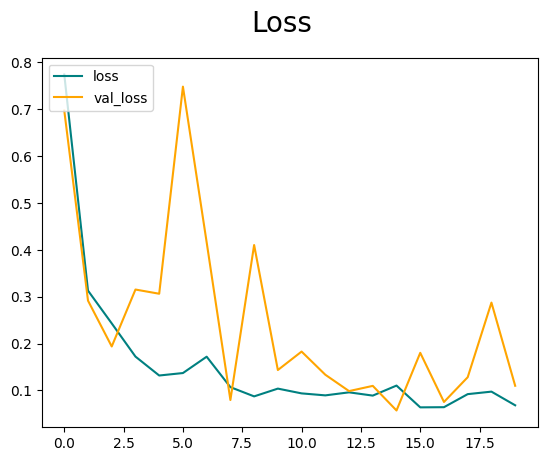

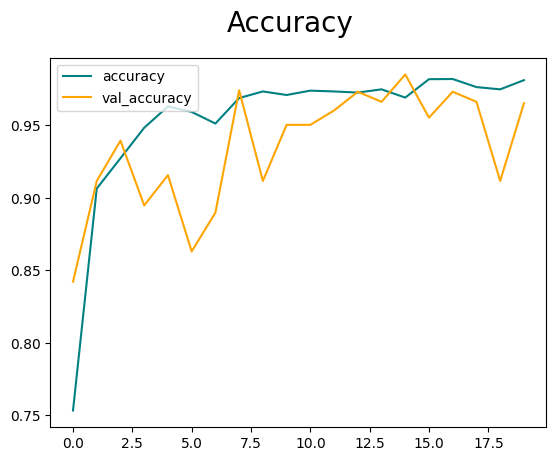

In [19]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [20]:
import numpy as np

<h1>Testing</h1>

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


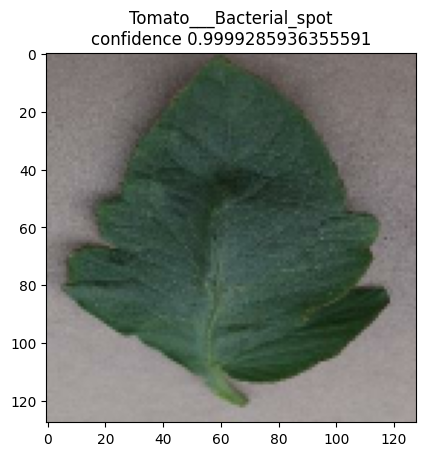

In [21]:
path = r'/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val/Tomato___Bacterial_spot/01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_Bact.Sp 2984.JPG'
img = tf.io.decode_jpeg(tf.io.read_file(path),channels=D)
img = tf.image.resize(img,[H,W])
img = tf.cast(img,dtype=tf.float32)
pred = model.predict(tf.expand_dims(img,axis=0))
result = np.argmax(pred)
conf = pred[0][result]

plt.imshow(img/255)
plt.title(f"{inverse_data_dict[result]}\nconfidence {conf}")
plt.show()
